In [1]:
import numpy as np
import polars as pl
from aeon.datasets.tsc_datasets import univariate
from autotsc import utils
from aeon.visualisation import plot_critical_difference
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect()

/tmp/ipykernel_3028576/2919427637.py:1: UserWarning: '(default_)region' not set; polars will try to get it from bucket

Set the region manually to silence this warning.
  rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect()


In [3]:
def filter_results(rdf, resampled: bool = False):
    excluded_models = [
        'quant-catboost',
        #'mr-hydra-sgd',
        #'mr-hydra',
        'loky-stacker-v5-r1',
        'mr-hydra-baseline',
        'u-rstsf',
        #'cumsum-mr-hydra',
        'rdst',
        'stacker-v4-r1',
        'drcif',
        'hivecotev2',
        #'rank-mr-hydra',
        #'scale-mr-hydra',
        'catch22',
        'quant',
        #'downsample-mr-hydra',
        #'polar-angle-mr-hydra',
        #'difference-mr-hydra',
        #'polar-magnitude-mr-hydra',
        'rstsf'
    ]
    
    return (
        rdf
        .filter(~pl.col("model").is_in(excluded_models))
        .filter(pl.col("resampled") == resampled)
    )

df = filter_results(rdf, resampled=True)
df

dataset,model,run,resampled,test_accuracy
str,str,i64,bool,f64
"""GunPointAgeSpan""","""polar-angle-mr-hydra""",500,true,0.993671
"""PLAID""","""mr-hydra-kbest-1000""",500,true,0.910615
"""DistalPhalanxTW""","""downsample-mr-hydra""",500,true,0.57554
"""GunPointAgeSpan""","""downsample-mr-hydra""",300,true,0.914557
"""MiddlePhalanxOutlineCorrect""","""difference-mr-hydra""",300,true,0.817869
…,…,…,…,…
"""EOGHorizontalSignal""","""loky-stacker-v5-soft-rf""",500,true,0.870166
"""FreezerSmallTrain""","""difference-mr-hydra""",400,true,0.988421
"""FreezerRegularTrain""","""rank-mr-hydra""",100,true,0.942105


In [4]:
import seaborn as sns

/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 26.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 31.2% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/gasper_p/workspace/repos/AutoTSC/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 52.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.war

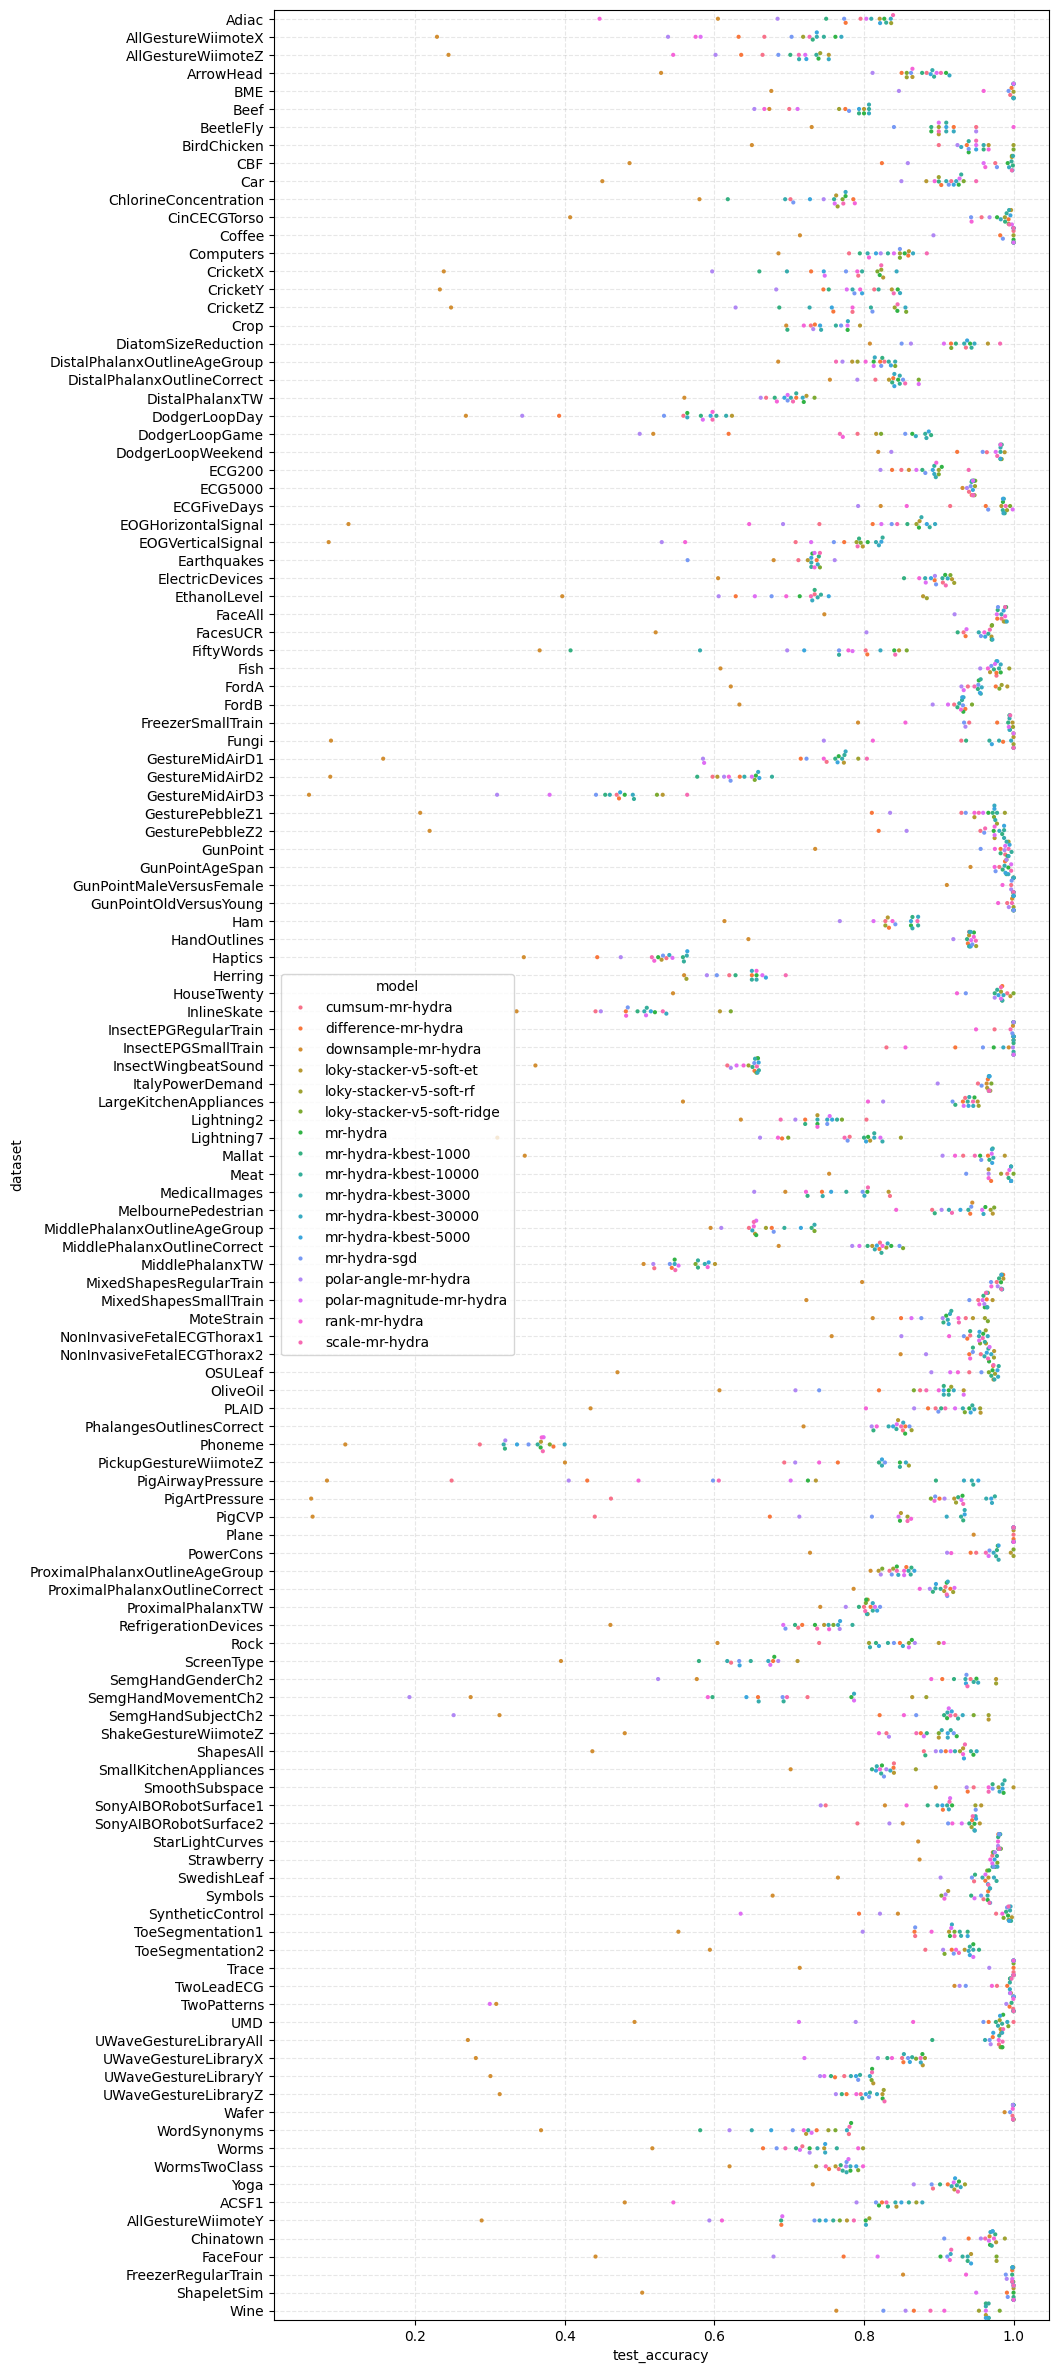

In [5]:
ax = sns.swarmplot(data=df.group_by(['dataset', 'model']).mean().sort(['model', 'dataset']), y="dataset", x="test_accuracy", hue="model", size=3)
ax.figure.set_size_inches(10, 30)
ax.grid(True, linestyle="--", alpha=0.3)

In [6]:
c = df.group_by(['dataset', 'model']).mean().sort(['model', 'dataset'])
v1 = c.filter(pl.col("model") == "mr-hydra")["test_accuracy"].to_numpy()
v2 = c.filter(pl.col("model") == "mr-hydra-kbest-30000")["test_accuracy"].to_numpy()

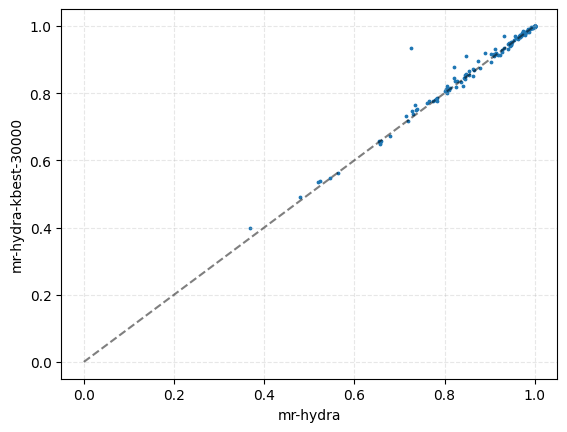

In [7]:
plt.scatter(v1, v2, s=3)
plt.xlabel("mr-hydra")
plt.ylabel("mr-hydra-kbest-30000")
plt.grid(True, linestyle="--", alpha=0.3)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

In [8]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

In [9]:
rk_models = [c for c in rdf['model'].unique().to_list() if 'kbest' in c]
v = rdf.pivot(values="test_accuracy", index="dataset", on="model", aggregate_function="mean").select(['dataset'] + rk_models)
joined = v.join(stats, on="dataset").sort("n_train")
joined

dataset,mr-hydra-kbest-30000,mr-hydra-kbest-10000,mr-hydra-kbest-5000,mr-hydra-kbest-3000,mr-hydra-kbest-1000,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""DiatomSizeReduction""",0.961765,0.962092,0.958497,0.955882,0.948366,16,306,4,345
"""DodgerLoopGame""",0.866142,0.870866,0.876378,0.874803,0.879528,17,127,2,288
"""InsectEPGSmallTrain""",0.993173,1.0,1.0,1.0,1.0,17,249,3,601
"""DodgerLoopWeekend""",0.983333,0.983333,0.983333,0.983333,0.984127,18,126,2,288
"""Fungi""",0.998387,0.974194,0.975269,0.985484,0.945699,18,186,18,201
…,…,…,…,…,…,…,…,…,…
"""PhalangesOutlinesCorrect""",0.845455,0.835664,0.831352,0.828555,0.809091,1800,858,2,80
"""FordA""",0.954697,0.955076,0.955227,0.956288,0.952727,3601,1320,2,500
"""FordB""",0.881728,0.879259,0.877531,0.875432,0.872099,3636,810,2,500


In [10]:
ranks = pl.DataFrame(joined.select(rk_models).to_pandas().rank(axis=1, ascending=False)).rename(lambda c: f"rank_{c}")
conc = pl.concat([joined, ranks], how="horizontal")
conc

dataset,mr-hydra-kbest-30000,mr-hydra-kbest-10000,mr-hydra-kbest-5000,mr-hydra-kbest-3000,mr-hydra-kbest-1000,n_train,n_test,n_classes,series_length,rank_mr-hydra-kbest-30000,rank_mr-hydra-kbest-10000,rank_mr-hydra-kbest-5000,rank_mr-hydra-kbest-3000,rank_mr-hydra-kbest-1000
str,f64,f64,f64,f64,f64,i64,i64,i64,i64,f64,f64,f64,f64,f64
"""DiatomSizeReduction""",0.961765,0.962092,0.958497,0.955882,0.948366,16,306,4,345,2.0,1.0,3.0,4.0,5.0
"""DodgerLoopGame""",0.866142,0.870866,0.876378,0.874803,0.879528,17,127,2,288,5.0,4.0,2.0,3.0,1.0
"""InsectEPGSmallTrain""",0.993173,1.0,1.0,1.0,1.0,17,249,3,601,5.0,2.5,2.5,2.5,2.5
"""DodgerLoopWeekend""",0.983333,0.983333,0.983333,0.983333,0.984127,18,126,2,288,3.5,3.5,3.5,3.5,1.0
"""Fungi""",0.998387,0.974194,0.975269,0.985484,0.945699,18,186,18,201,1.0,4.0,3.0,2.0,5.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""PhalangesOutlinesCorrect""",0.845455,0.835664,0.831352,0.828555,0.809091,1800,858,2,80,1.0,2.0,3.0,4.0,5.0
"""FordA""",0.954697,0.955076,0.955227,0.956288,0.952727,3601,1320,2,500,4.0,3.0,2.0,1.0,5.0
"""FordB""",0.881728,0.879259,0.877531,0.875432,0.872099,3636,810,2,500,1.0,2.0,3.0,4.0,5.0


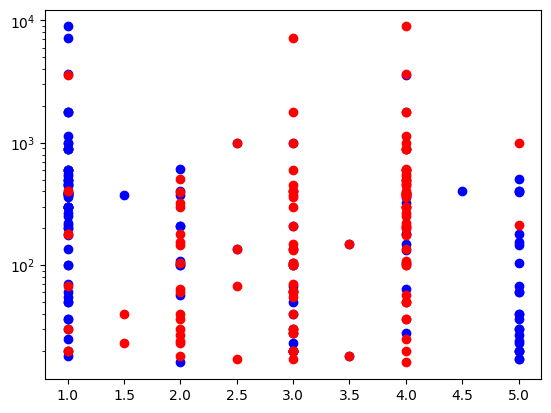

In [11]:
plt.scatter(conc['rank_mr-hydra-kbest-30000'], conc['n_train'], color='blue')
plt.scatter(conc['rank_mr-hydra-kbest-3000'], conc['n_train'], color='red')
# set y log scale
plt.yscale('log')

In [12]:
from scipy.stats import spearmanr
corr, pval = spearmanr(conc['rank_mr-hydra-kbest-30000'].to_numpy(), conc["n_train"].to_numpy())
corr

np.float64(-0.4582149407955062)

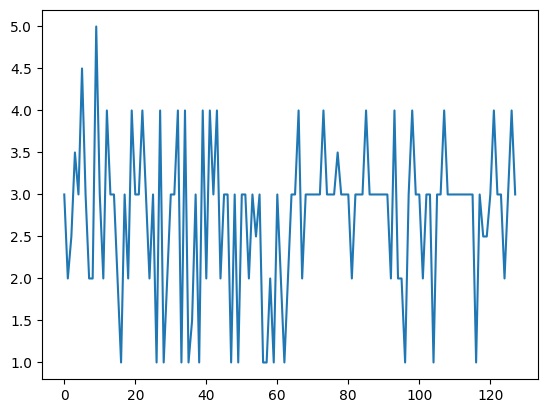

In [13]:
v = conc.sort("n_train").select(['rank_mr-hydra-kbest-5000', 'rank_mr-hydra-kbest-30000'])
plt.plot(v['rank_mr-hydra-kbest-5000'])

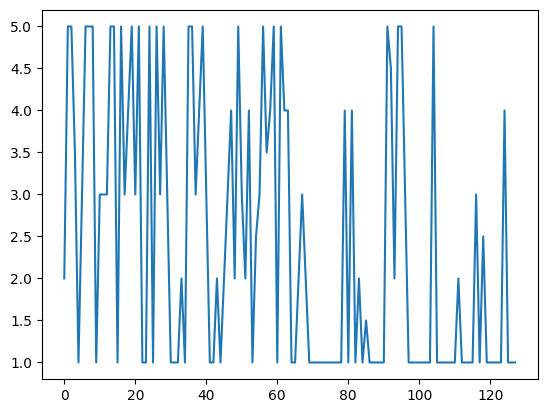

In [14]:
plt.plot(v['rank_mr-hydra-kbest-30000'])

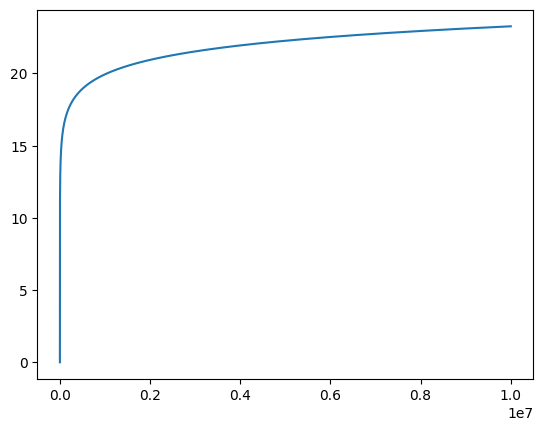

In [15]:
x = np.array(range(10_000_000))
c = np.log2(x + 1)
plt.plot(x, c)

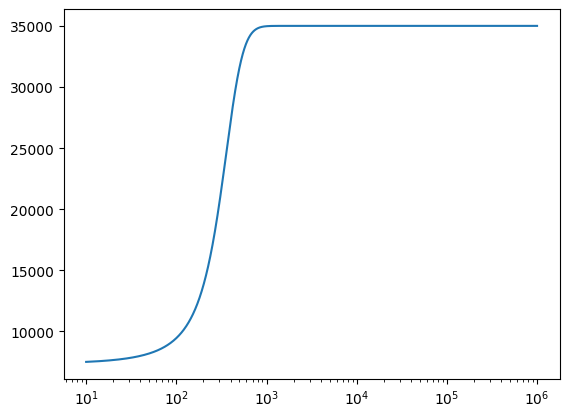

In [16]:
def optimal_k(n_train, k_min=6000, k_max=35000, midpoint=300, steepness=0.010):
    return k_min + (k_max - k_min) / (1 + np.exp(-steepness * (n_train - midpoint)))

x = np.array(range(10, 1_000_000))
y = optimal_k(x)
plt.plot(x, y)
# x axis is log
plt.xscale('log')

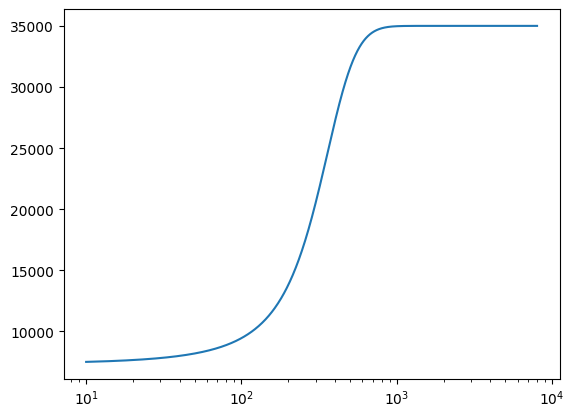

In [17]:
x = np.array(range(10, 8_000))
y = optimal_k(x)
plt.plot(x, y)
# x axis is log
plt.xscale('log')